# Why seaborn?
- provides a layer of abstraction
- because of the layer of abstraction simpler to use
- more graphs included
- default graphs are better looking

# types of object

**1. Figure :**   the area where the graphs are plotted . 
 - each figure can uphold multiple same and differenty types of graph<br>


**2. Axis :**  the axis on which graph is plotted .<br> 

-  Each figure object can have has multiple axis object
-  2 Different functinos can give same graph . this is because, one of them may be figure level graph and one is maybe axis level graph

# types of function
      - Figure level
      - Axis level
- we can  replicate different axis level functionn with a single figure level function
- in case of figure level fn the label is situated out side the graph whereas in axis level its inside the graph

# Classification of plot 
- relational plot - scatter plot ,line plot
- Distributive plot - Histogram , KDE plot ,Rug plot
- Categorical plot - barplot , count plot , boxplot ,violin plot , swam plot
- Refression plot - 
- Matrix plot - Heatmap , Cluster map
- Multiplots - join plot , pair plot

# 1. Relational Plot
- to see the statistical relation between 2 or more variables
- bivariate analysis
- scatter and line plot

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px # here will use fot datasets

In [2]:
tips = sns.load_dataset('tips')
tips #it is a dataset about a resturant

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


- scatter plot

     - here x and y labels are automatically setted (also can be manually edited)

<Axes: xlabel='total_bill', ylabel='tip'>

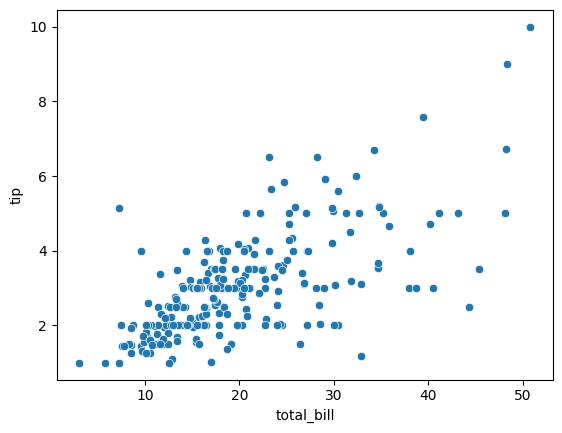

In [3]:
#syntax - sns.scatterplot(dataframe_name,x='column at x axis',y='column at y axis')
#        - this is a axis level function


sns.scatterplot(tips,x='total_bill',y='tip')# scatter plot  for tips vs total_bill


- relplot

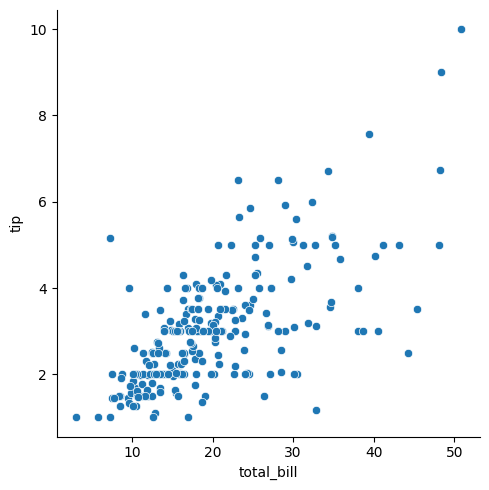

In [4]:
# alternative of scatterplot which is figure level plot -> relplot
#syntax - sns.relplot(data=<dataframe_name>,x='column name at x axis',y='column name at y axis',kind='scatter')
# default shape of figure level function is square

sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter')


customization-

<Axes: xlabel='total_bill', ylabel='tip'>

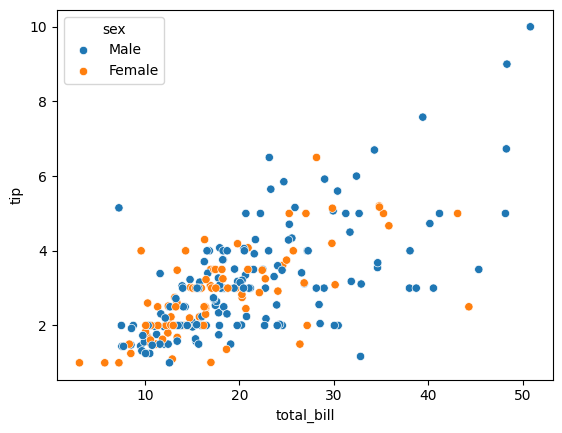

In [5]:
#hue - give different color to points according to different values of the column passed in hue
# ->automatically adds label to color. 
# ->also can be used in relplot
#syntax - hue='column name'

sns.scatterplot(tips,x='total_bill',y='tip',hue='sex') 
# give different color to points accordin to there gender


<Axes: xlabel='total_bill', ylabel='tip'>

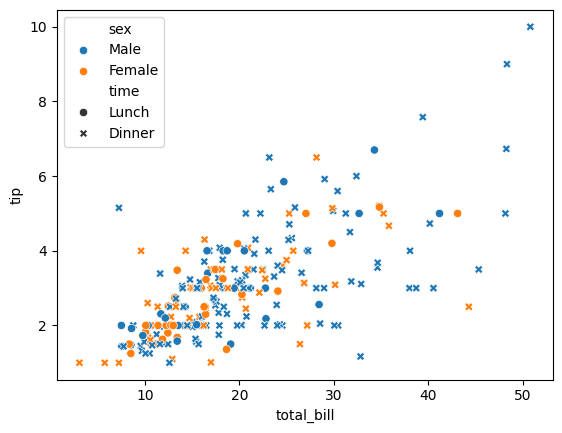

In [6]:
#style - gives different marker according to values of the column passed
# -> autimatically adds the label of marker
# -> can be used in relplot

#syntax - style='column name'
sns.scatterplot(tips,x='total_bill',y='tip',hue='sex',style='time')# gives different marker for dinner and lunch


<Axes: xlabel='total_bill', ylabel='tip'>

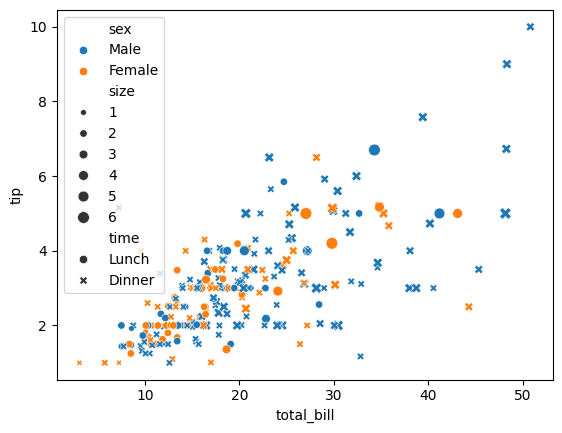

In [7]:
#size - varies the size of the marker plotted according to the value of the column passed
# -> can be used in relplot
# -> autmoically adds label for understanding the relation between size and value of column

#syntax - style = 'column name'
sns.scatterplot(tips,x='total_bill',y='tip',hue='sex',style='time',size='size') # size of plot will be more if more number of customer are on the order

In [8]:
gap = px.data.gapminder() # data set of countries different info in different years
gap

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


- lineplot
    - just connect the points plotted by an scatter plot
    - prefered when x axis has time 

<Axes: xlabel='year', ylabel='lifeExp'>

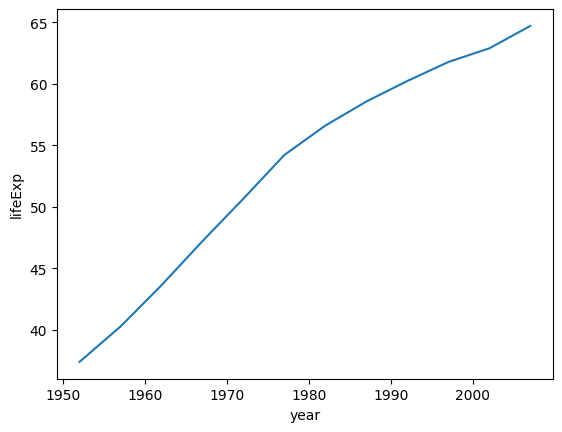

In [9]:
#syntax - sns.lineplot(data=<dataframe name>,x='column at x',y='column at y')
# axis level fn

#plot graph of life expectency of india from 1952 till 2007

india=gap[gap['country'] == 'India']

sns.lineplot(data=india,x='year',y='lifeExp')

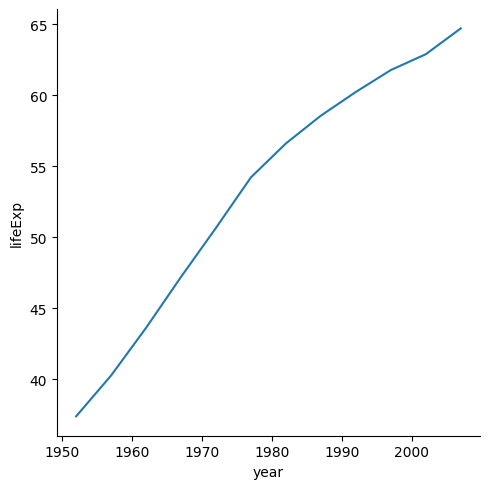

In [10]:
#lineplot using relplot
 # just pass line as value of kind parameter
sns.relplot(data=india,x='year',y='lifeExp',kind ='line')

customization
- all are same for relplot and lineplot

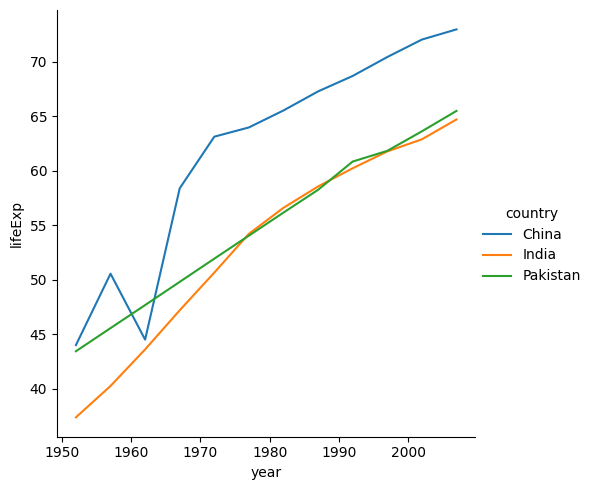

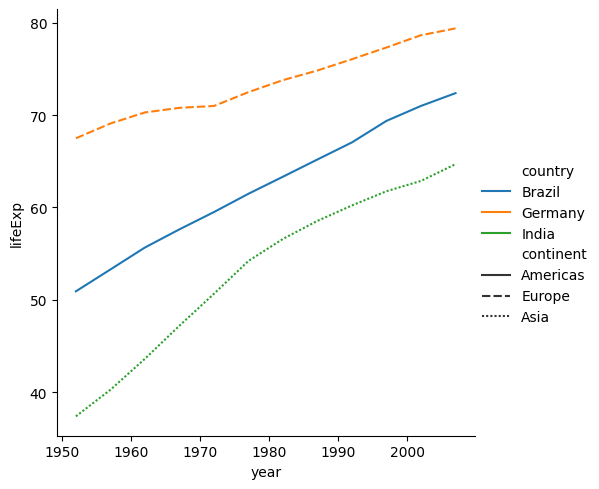

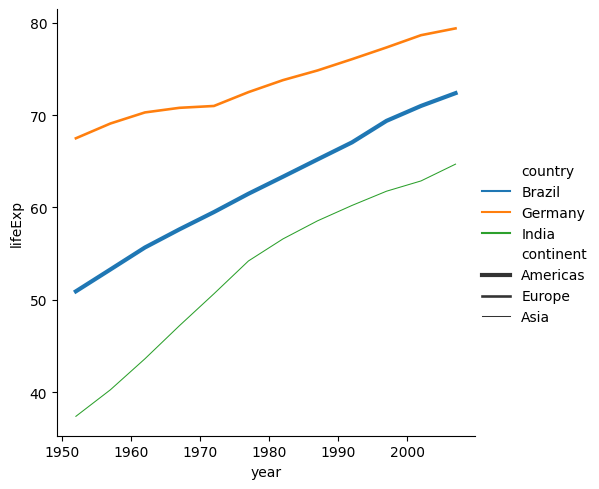

In [11]:
#hue - same as in scatter
#style-same as in scattter
#size - varies the thickness based on the column passed 

#plotting graph of india ,pakistan , china side by side
temp = gap[gap['country'].isin(['India','Pakistan','China'])]
sns.relplot(temp,x='year',y='lifeExp',kind='line',hue='country') # give plot of 3 countries with different color for each country

temp = gap[gap['country'].isin(['India','Brazil','Germany'])]
sns.relplot(temp,x='year',y='lifeExp',kind='line',hue='country',style='continent') # adds different style of graph based on there continent



sns.relplot(temp,x='year',y='lifeExp',kind='line',hue='country',size='continent') # varies thickness of graph based on there continent


- facet plot
    - plot different graph for data belonging to different value of a column
    - use parameter col or row at place of hue . hue->col , hue->row
    - figure level plot -> works with relplot but not with scatterplot and lineplot

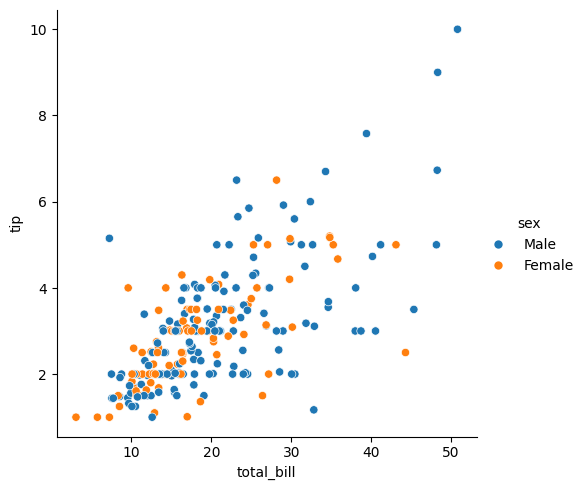

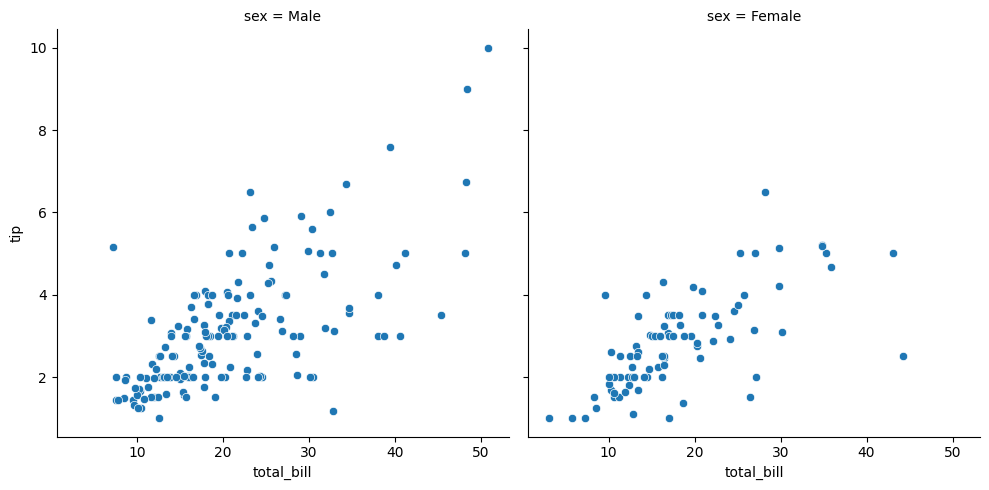

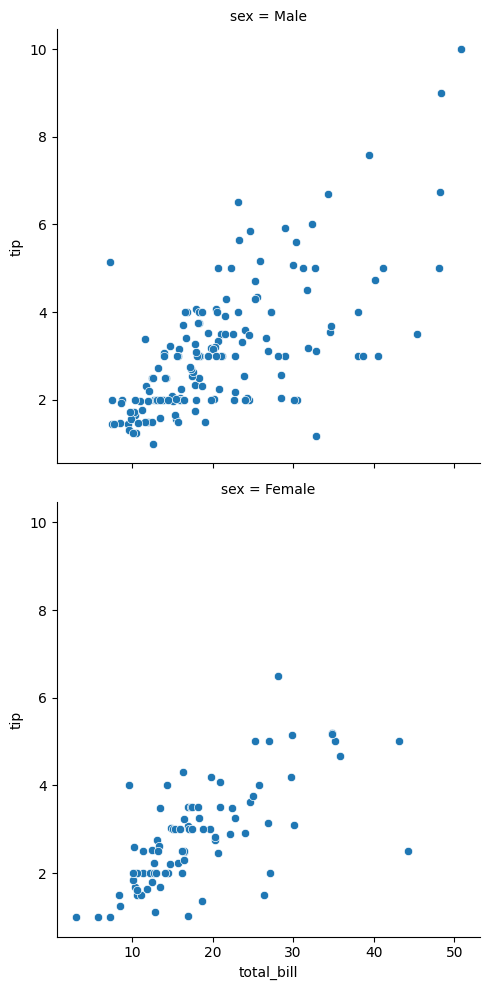

In [12]:
sns.relplot(data=tips,x='total_bill', y='tip',kind='scatter',hue='sex') #this gives different color to different vlaue of gender

#if we want to plot seprate graph for male and female
sns.relplot(data=tips,x="total_bill",y='tip',kind='scatter',col='sex')


#if we want the different graphs to be in a row then use row
sns.relplot(data=tips,x="total_bill",y='tip',kind='scatter',row='sex')

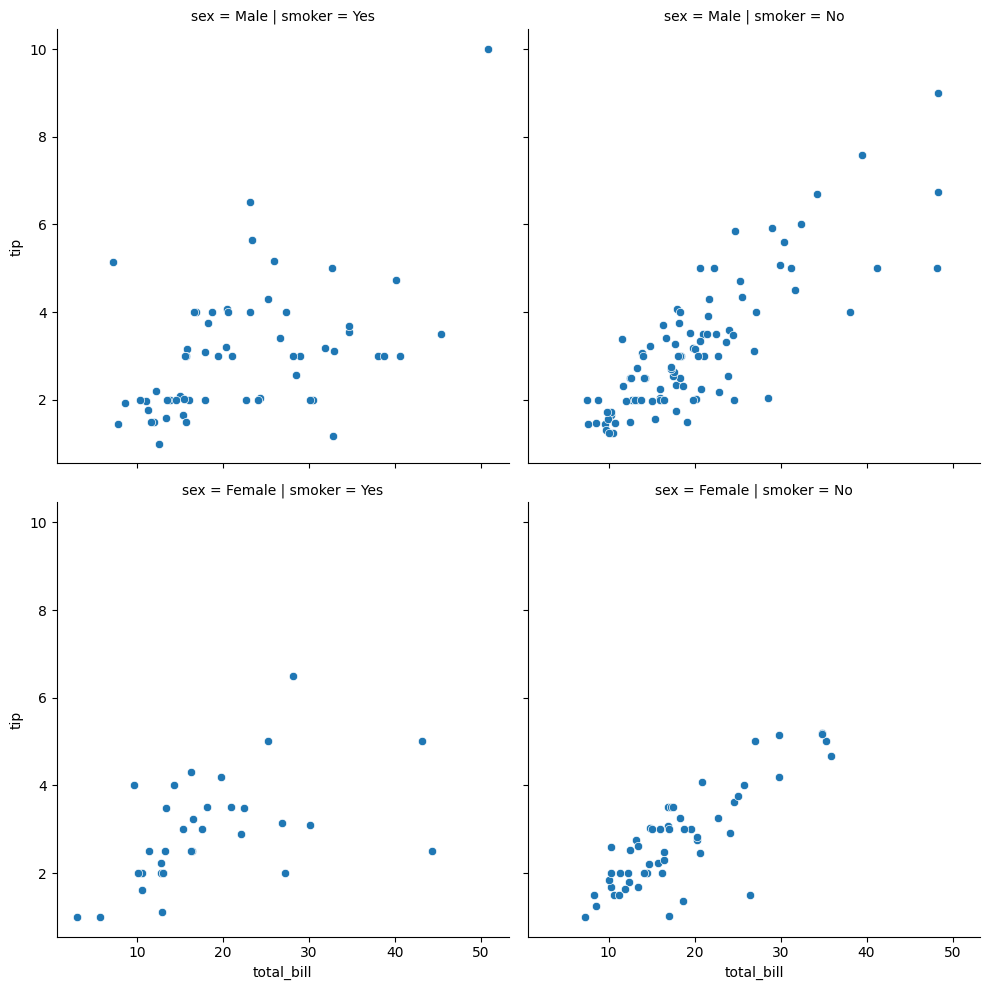

In [13]:
# we can use both row and col together 
#eg in col show for smoker or not and in row show for sex
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='smoker',row='sex')

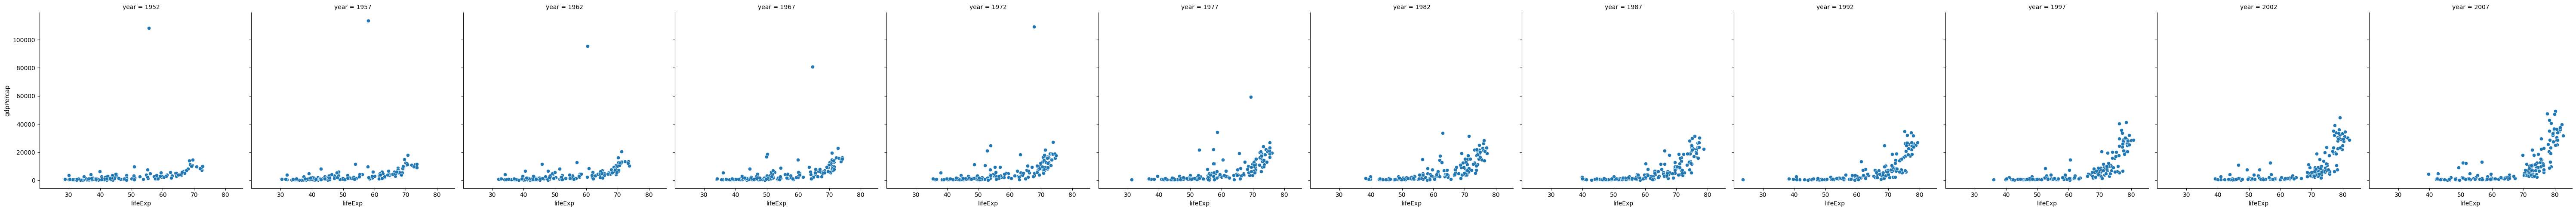

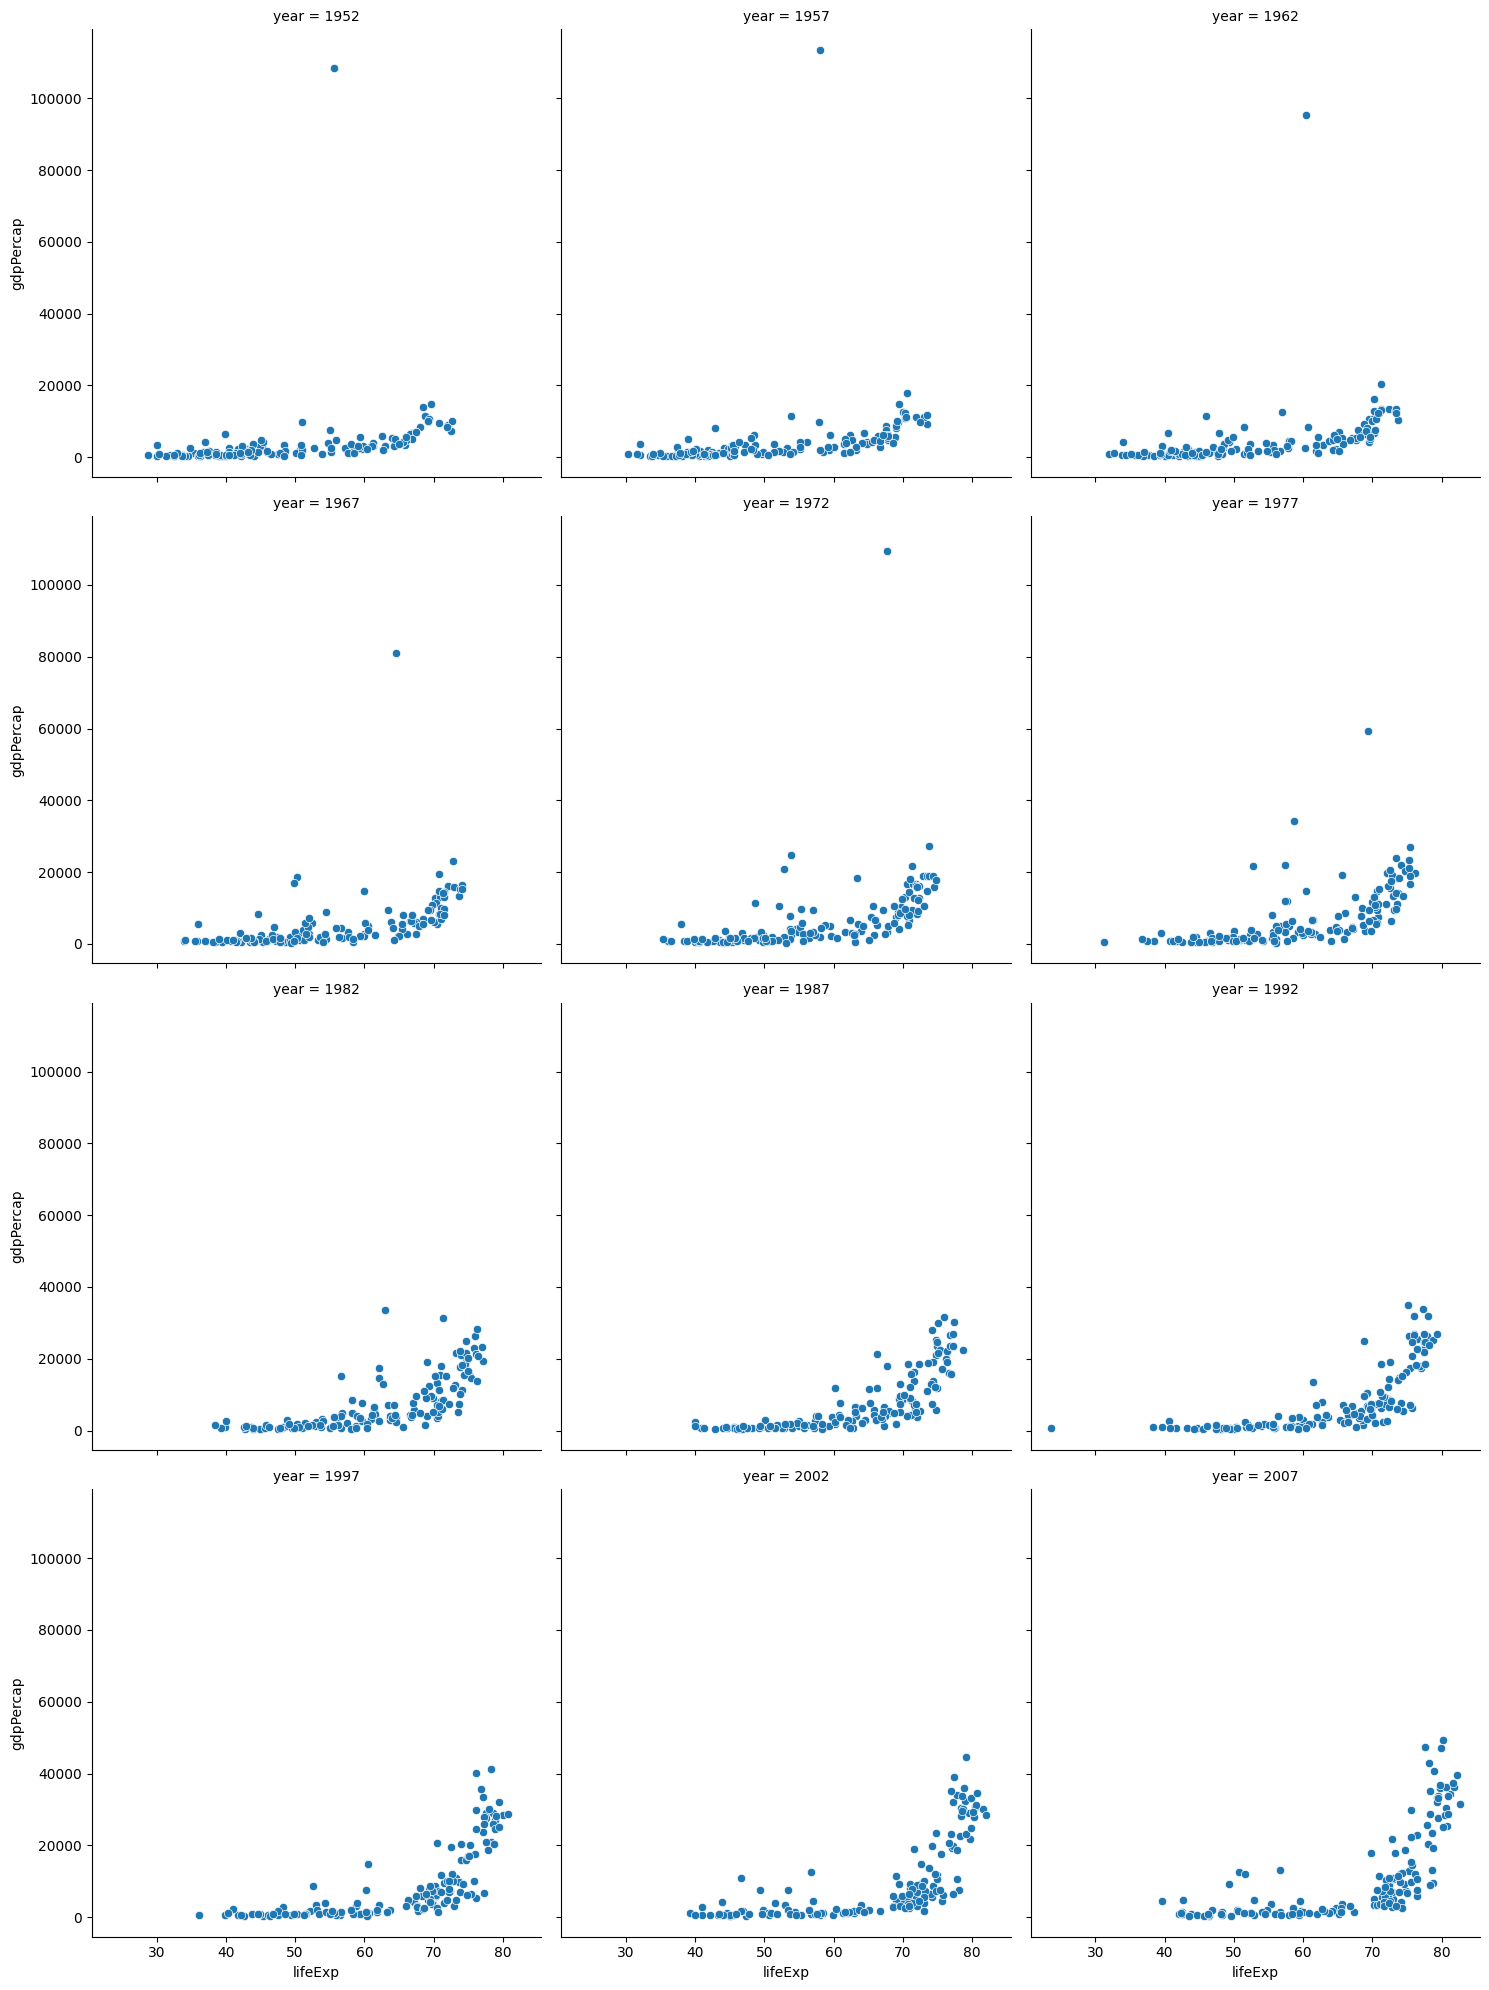

In [14]:
# col_wrap - can control maximum how many graphs can be in a single row. extra will be send to the below row
# syntax = col_wrap = value

sns.relplot(gap,x='lifeExp',y='gdpPercap',kind='scatter',col='year')# this will plot all years graph in a single row
#its not feasible to study this so we make a bound for no of graphs each row
sns.relplot(gap,x='lifeExp',y='gdpPercap',kind='scatter',col='year',col_wrap=3)# this will plot all years graph in a multiple rows 
#more feasible to study



# 2. Distribution plots

- used for univariate analysis
- used to findout the distribution
- range of the observation
- central tendency <br>
     we can find if there<br>
- is the data bimodal?
- are there outliners ?

Plots - 
- histplot
- kdeplot
- rugplot

In [15]:
#figure level fn - displot
# axis level fn - histplot - for histograms
#               , kdeplot - for 
#               , rugplot - for 


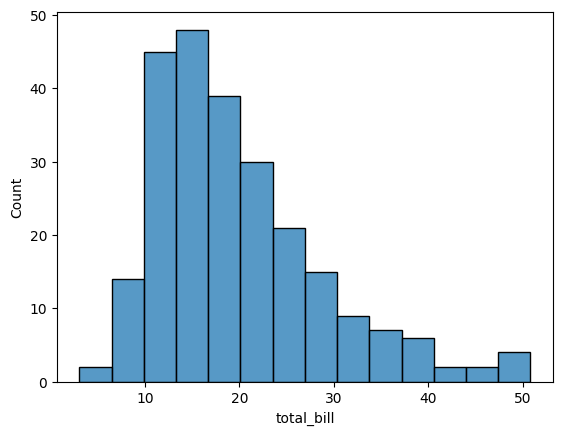

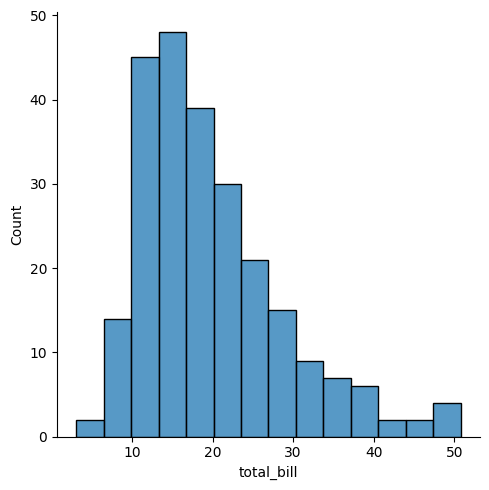

In [16]:
#plotting univariate histogram
sns.histplot(data=tips,x='total_bill') # plots hostogram for total_bill
# atomatically makes the bin 
 

#using  displot
sns.displot(data=tips,x='total_bill',kind='hist')

<Axes: xlabel='total_bill', ylabel='Count'>

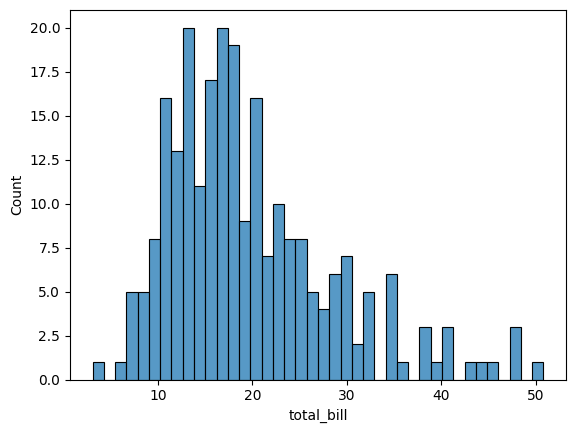

In [17]:
#bins parameter - can change number of bins bu passing an parameter bins=<num of bins>
sns.histplot(data=tips,x='total_bill',bins=40)


<Axes: xlabel='day', ylabel='Count'>

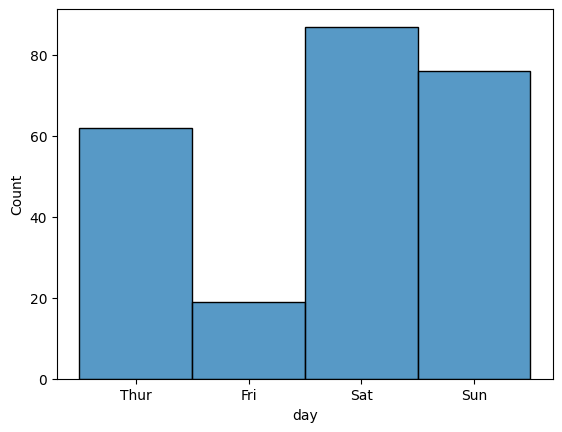

In [18]:
# for categorical variables
# discrete bins are automatically set for the categorical variables

sns.histplot(data=tips,x='day')

# this is not a  histogram rather than it is a countplot

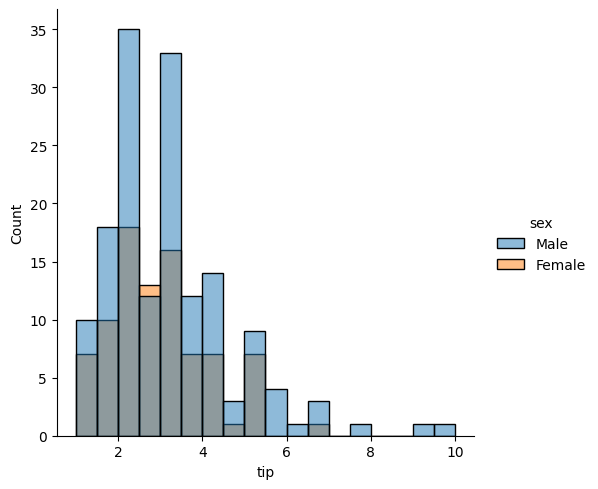

In [19]:
#hue parameter
sns.displot(data=tips,x='tip',kind='hist',hue='sex')
# it will show males and female histogram with different color so can be easily analysed

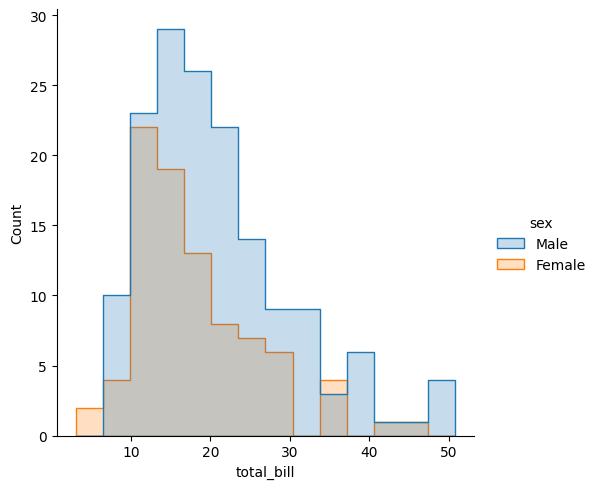

In [20]:
# for removing bar to only see the outline of histogram pass a parameter element='step'
sns.displot(data=tips,x='total_bill',kind='hist',hue='sex',element='step')

In [21]:
titanic=sns.load_dataset('titanic') #data of all the passenger who were traveling in the titanic
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


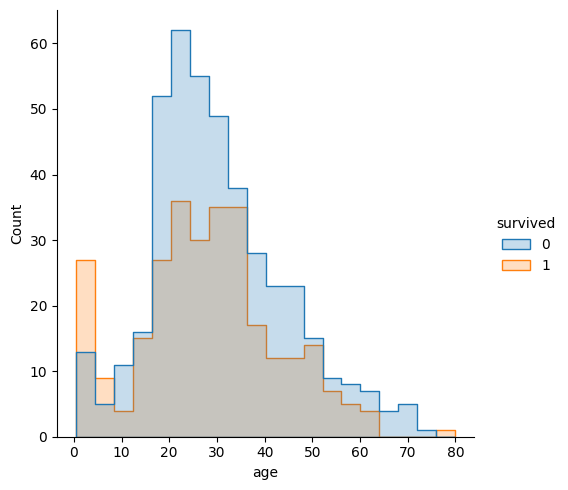

In [22]:
#plot age histogram also compare data of passenger survived and dead of each age
sns.displot(data=titanic,x='age',kind='hist',hue='survived',element='step')

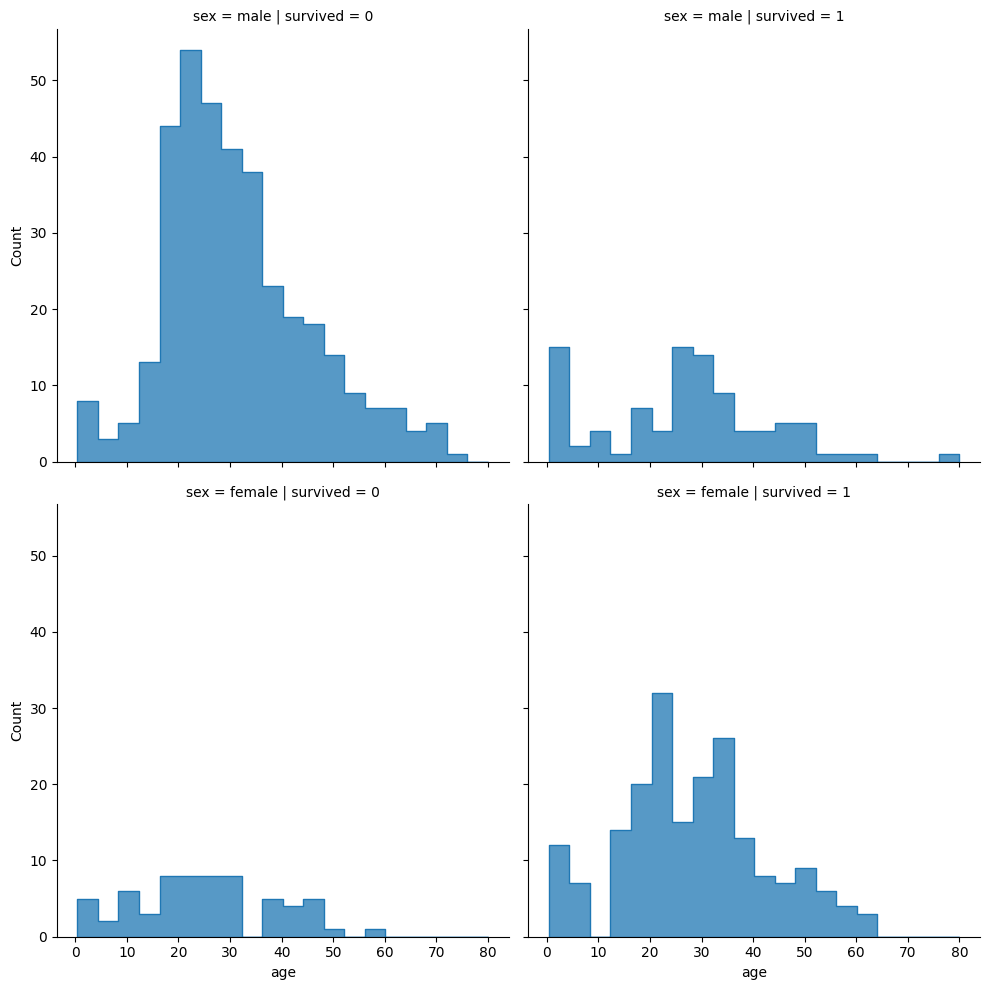

In [23]:
# facetplot in histogram - same as others
# will not work on histplot fn
sns.displot(data=titanic,x='age',kind='hist',col='survived',row='sex',element='step')

- kdeplot

rather than using discrete bins , a KDE smooths the observations with a gaussian kernel, producing a continuous density estimate

    - y axis represents probabilty of occurence of the x value 
    - in other words y axis represents probability density of x axis

<br> <br>
- more prefered than histogram


<Axes: xlabel='total_bill', ylabel='Density'>

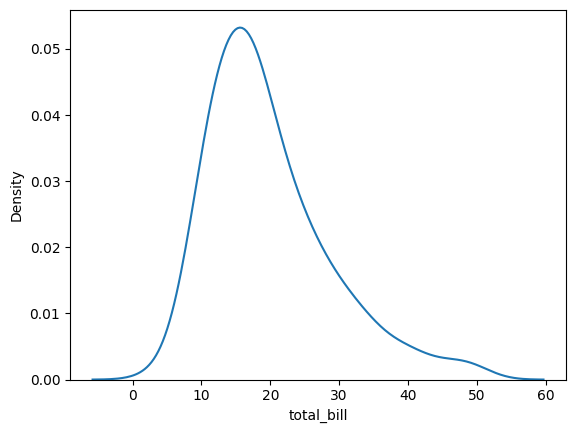

In [24]:
sns.kdeplot(data=tips,x='total_bill')

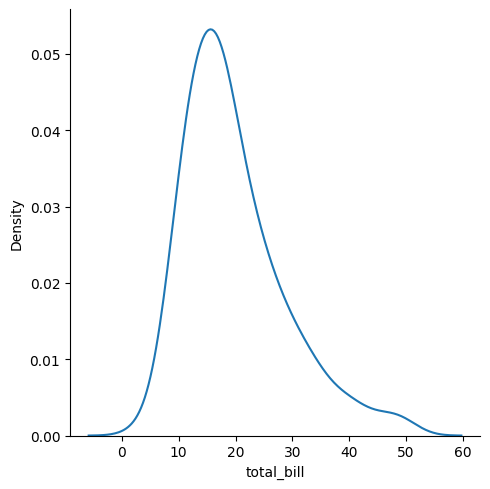

In [25]:
#kdeplot using displot

sns.displot(data=tips,x='total_bill',kind='kde')

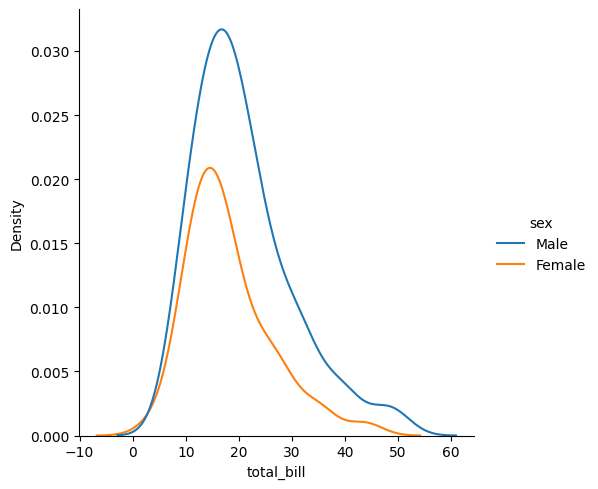

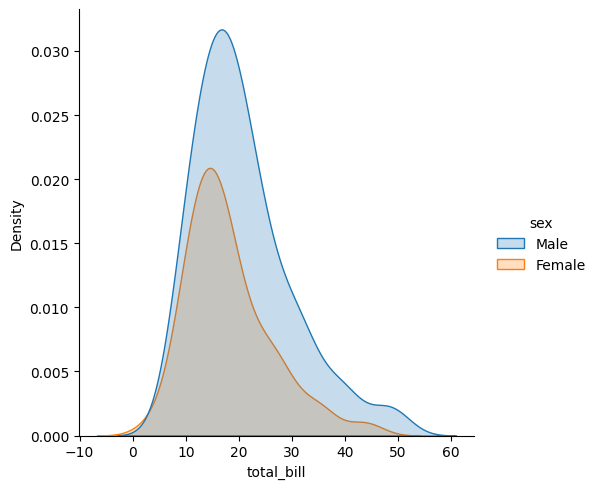

In [26]:
# hue - can seprate plot bassed on value of a specific column
# can be used in both fig lavel and axis level
sns.displot(data=tips,x='total_bill',kind='kde',hue='sex')
#seprated plotted line for male and female


#fill - fils the graph when value passes as true
sns.displot(data=tips,x='total_bill',kind='kde',hue='sex',fill=True)


- rugplot
 plot marginal distribution by drawing ticks along x and y axis

    - is intended to complement other plots by showing the location of individual observations in an unobtrusive way.
    - marks all the values in column at x axis

<Axes: xlabel='total_bill', ylabel='Density'>

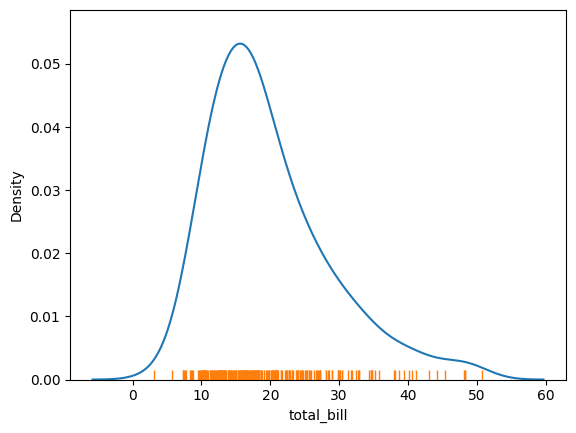

In [27]:
sns.kdeplot(data=tips,x='total_bill') 
# now rugplot will be used as additional helpful data fot above plot
sns.rugplot(data=tips,x='total_bill')


- Bivariate histogram
bins the data within rectangle that tile the plot and then shows the count of observations within each rectngle with fill color.

     -plots histogram for both x and y axis then take there intersection to form the rectangle for each combo of x and y . fill more color where more values lie
     - darker the color more density of data


<Axes: xlabel='total_bill', ylabel='tip'>

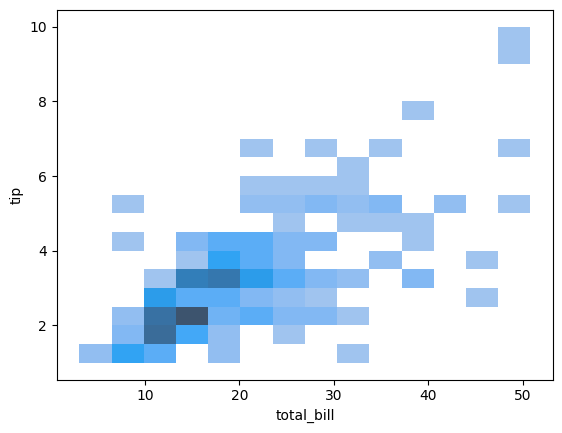

In [28]:
sns.histplot(data=tips,x='total_bill',y='tip')

- Bivariate kdeplot
smoothes the (x,y) observations with a 2D gausian 

     - closer the lines become denser the data is at that point

<Axes: xlabel='total_bill', ylabel='tip'>

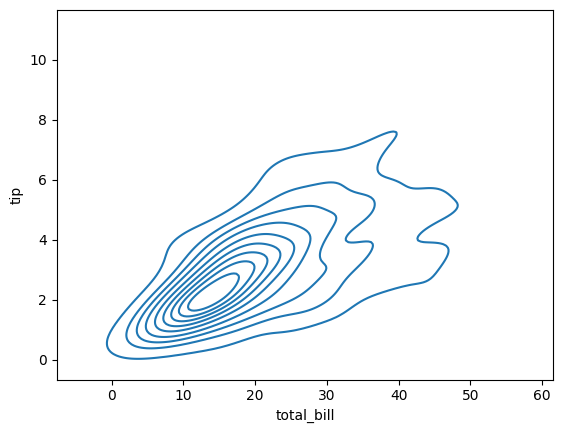

In [29]:
sns.kdeplot(data=tips,x='total_bill',y='tip')

# 3. Matrix plot

- Heat map
- clustermap

- HeatMap
     
     - plots rectangular data as color-encoded matrix
     - axis level fn
     - no corresponding figure level fn

In [30]:
gap

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


<Axes: xlabel='year', ylabel='country'>

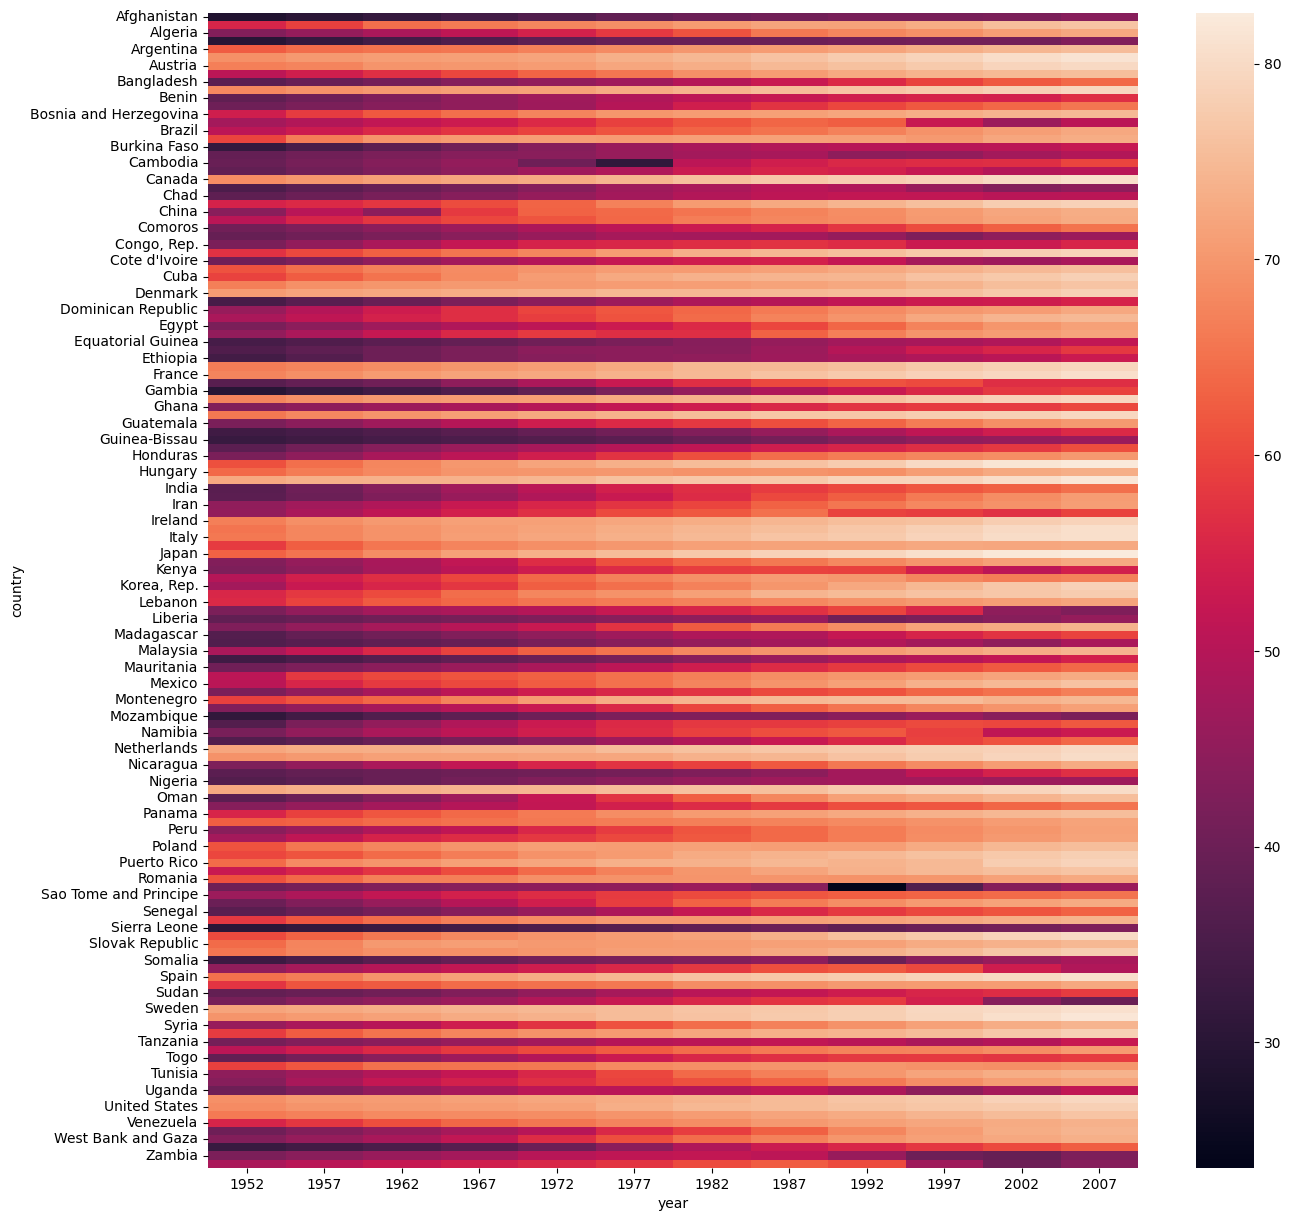

In [31]:
# plot life expectency of each contry on each year

data = gap.pivot(index='country',columns='year',values='lifeExp')
plt.figure(figsize=(15,15))
sns.heatmap(data=data)

customizations -

<Axes: xlabel='year', ylabel='country'>

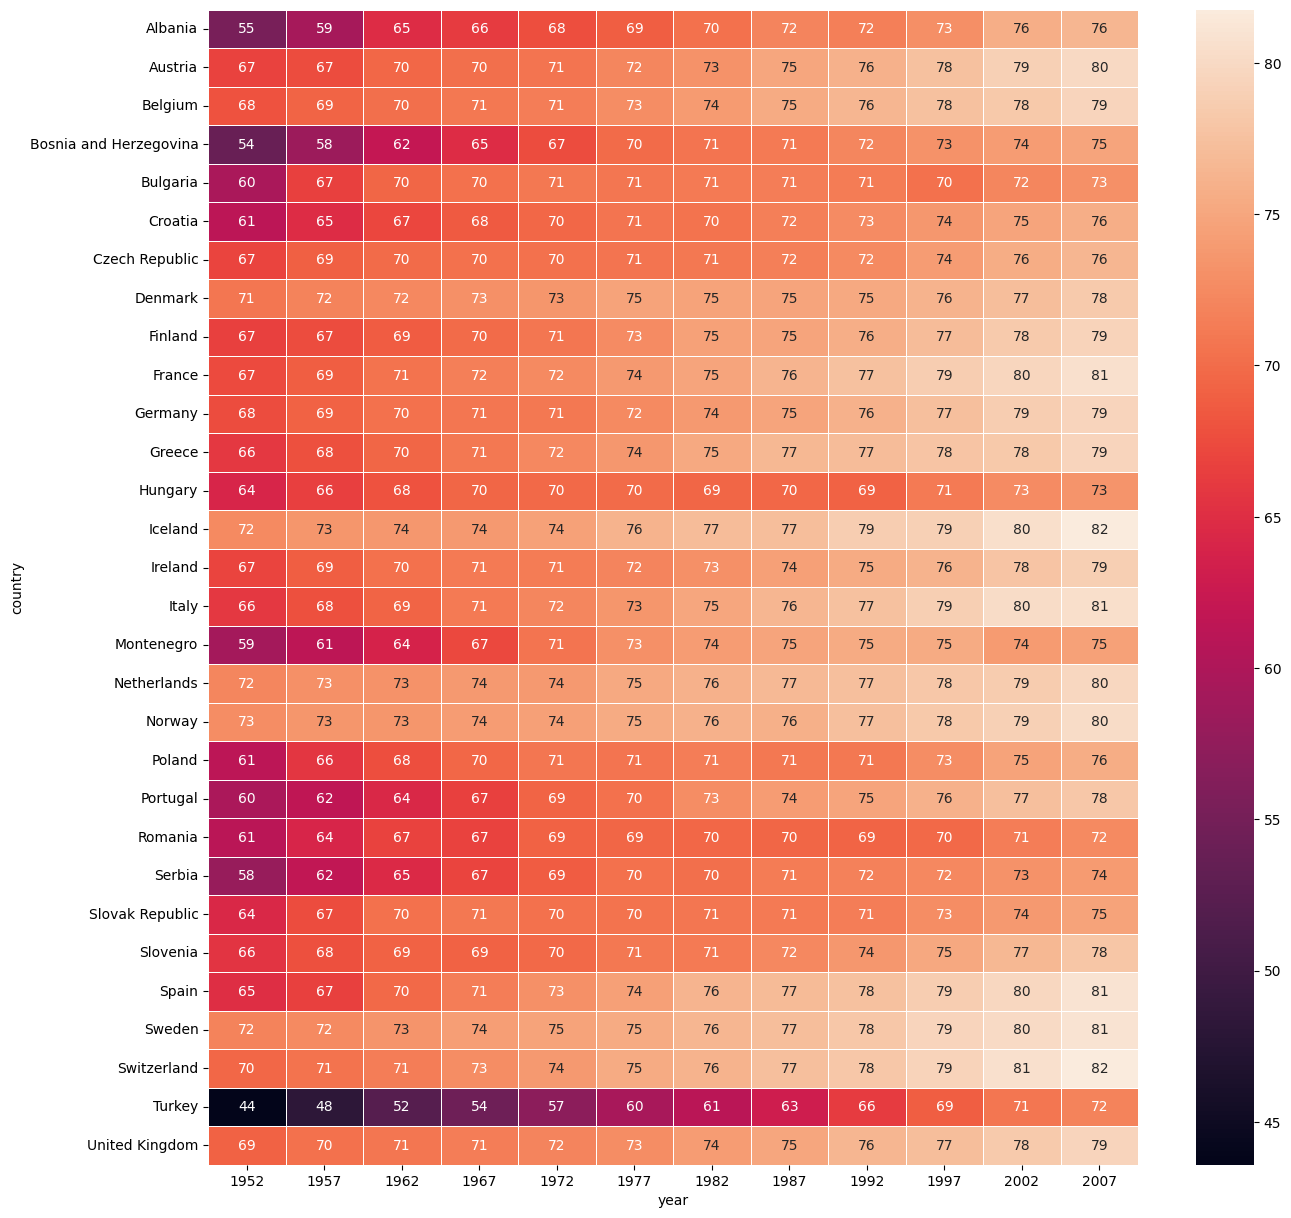

In [32]:
# annot - paramter which give color with value of each block 
#linewidth - parameter which adds gap between each block
#cmap - changes color mapping
eroupe = gap[gap['continent'] == 'Europe'].pivot(index='country',columns='year',values='lifeExp')
plt.figure(figsize=(15,15))
sns.heatmap(eroupe,annot=True,linewidths=0.4)# values will also appear

- clustermap

     - merges similar columns
     - plots a matrix dataset as a hierarchically-clustered heatmap
     - this function requires scipy to be available

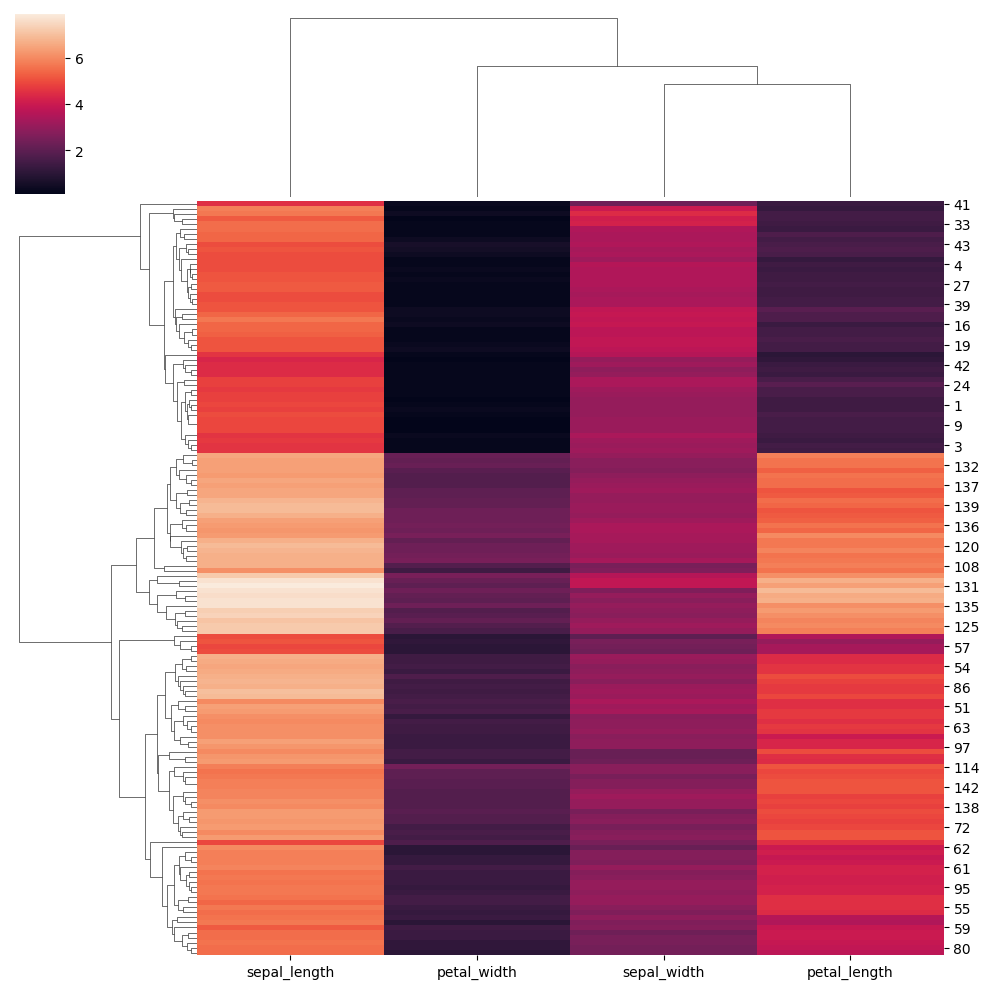

In [33]:
iris = px.data.iris()
import scipy as sp
# find flowers which are similar
sns.clustermap(iris.iloc[:,[0,1,2,3]])